# Ensemble Uncertainty Estimation for Semantic Segmentation

This notebook implements ensemble uncertainty estimation for Mask2Former semantic segmentation using TorchUncertainty.

**Key Features:**
- Sequential model inference for memory efficiency
- TorchUncertainty metrics for uncertainty decomposition
- Per-class IoU and calibration analysis
- Comprehensive uncertainty statistics
- Optional visualization

**Uncertainty Types:**
- **Aleatoric**: Data noise uncertainty
- **Epistemic**: Model disagreement uncertainty  
- **Total**: Combined uncertainty

## 1. Setup and Imports

In [28]:
import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')
plt.style.use('default')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')

PyTorch version: 1.13.1+cu116
CUDA available: True
CUDA device: NVIDIA GeForce GTX 1080 Ti


In [29]:
# TorchUncertainty imports
try:
    from torch_uncertainty.metrics.diversity import Entropy, MutualInformation, VariationRatio
    from torch_uncertainty.metrics.calibration import CalibrationError
    from torch_uncertainty.metrics.others import AUSE
    print('✅ TorchUncertainty imported successfully')
    TORCH_UNCERTAINTY_AVAILABLE = True
except ImportError as e:
    print(f'❌ TorchUncertainty import failed: {e}')
    print('Falling back to torchmetrics for IoU calculation.')
    TORCH_UNCERTAINTY_AVAILABLE = False
    try:
        from torchmetrics import JaccardIndex
        print('✅ torchmetrics.JaccardIndex imported for IoU.')
    except ImportError as e2:
        print(f'❌ torchmetrics import failed: {e2}')
        print('Please install: pip install torchmetrics')
        sys.exit(1)

❌ TorchUncertainty import failed: No module named 'torch_uncertainty'
Falling back to torchmetrics for IoU calculation.
✅ torchmetrics.JaccardIndex imported for IoU.


In [30]:
# Project imports (adjust paths as needed)
SCRIPT_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

try:
    from src.models.mask2former import get_mask2former_model, get_preprocessor
    from src.data.coco_dataset import COCODataset, ImageSegmentationDataset
    from src.data.transforms import test_transform, target_transform
    from src.utils.palette import label2id, palette, id2label_remapped, remap_labels
    print('✅ Project modules imported successfully')
except ImportError as e:
    print(f'❌ Project import failed: {e}')
    print('Please ensure your project structure is correct')

✅ Project modules imported successfully


## 2. Configuration

In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if os.name == 'darwin':
    print("Running on macOS - adjusting paths accordingly")
    # Adjust paths for macOS if needed
    CONFIG = {
        'coco_json_path': '/Users/rk/Downloads/Thesis/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json',
        'dataset_root_dir': '/Users/rk/Downloads/Thesis/',
        'ensemble_models_dir': 'Output/',
        'output_dir': 'Output/uncertainty_visualizations_notebook',
        'checkpoint_files': [
            'best_model_551ouxf3.pt',
        ],
        'batch_size': 3,
        'max_visualize': 10,
        'num_workers': 0
    }
else:
    # Paths and configuration
    CONFIG = {
        'coco_json_path': "/scratch/s7rakuma/datasets/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json",
        'dataset_root_dir': "/scratch/s7rakuma/datasets/",
        'ensemble_models_dir': "/scratch/s7rakuma/MUSH/Output/",
        'output_dir': "Output/uncertainty_visualizations_notebook",
        'checkpoint_files': [
            'best_model_551ouxf3.pt',
            'model_epoch60_551ouxf3.pt',
            'model_epoch80_551ouxf3.pt',
            'model_epoch100_551ouxf3.pt'
        ],
        'batch_size': 20,
        'max_visualize': 10,
        'num_workers': 6
    }

if not os.path.exists(CONFIG['coco_json_path']):
    print(f"⚠️  Warning: COCO JSON not found at {CONFIG['coco_json_path']}")
    print('Please update the path in CONFIG above')
else:
    print('✅ COCO dataset path validated')

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print(f"Output directory: {CONFIG['output_dir']}")

num_classes = len(label2id)
print(f'Number of classes: {num_classes}')
print(f'Class mapping: {label2id}')

Using device: cuda
✅ COCO dataset path validated
Output directory: Output/uncertainty_visualizations_notebook
Number of classes: 8
Class mapping: {0: 0, 11: 1, 12: 2, 13: 3, 14: 4, 15: 5, 17: 6, 18: 7}


## 3. Data Loading

In [32]:
print('📁 Loading test dataset...')
base_test_ds = COCODataset(CONFIG['coco_json_path'], CONFIG['dataset_root_dir'], split='test')
test_dataset = ImageSegmentationDataset(base_test_ds, transform=test_transform, target_transform=target_transform, label2id=label2id)
print(f'✅ Test dataset loaded: {len(test_dataset)} samples')

📁 Loading test dataset...
✅ Test dataset loaded: 93 samples


In [33]:
def inference_collate_fn(batch):
    images, masks, orig_images, orig_masks = zip(*batch)
    preprocessor = get_preprocessor(num_classes)
    processed = preprocessor(list(images), segmentation_maps=list(masks), return_tensors='pt')
    return {
        'pixel_values': processed['pixel_values'],
        'original_images': list(orig_images),
        'original_segmentation_maps': list(orig_masks)
    }

test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, collate_fn=inference_collate_fn, num_workers=CONFIG['num_workers'])
print(f'✅ DataLoader created: {len(test_dataloader)} batches')

✅ DataLoader created: 5 batches


🔍 Testing single batch...
Batch shapes:
  - pixel_values: torch.Size([20, 3, 640, 360])
  - original_images: 20
  - original_segmentation_maps: 20


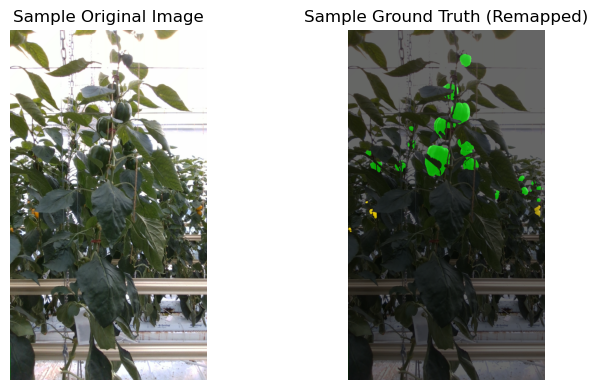

Sample GT shape: torch.Size([1280, 720])
Unique GT labels: [0 3 4 7]


In [34]:
print('🔍 Testing single batch...')
sample_batch = next(iter(test_dataloader))
print(f'Batch shapes:')
print(f'  - pixel_values: {sample_batch["pixel_values"].shape}')
print(f'  - original_images: {len(sample_batch["original_images"])}')
print(f'  - original_segmentation_maps: {len(sample_batch["original_segmentation_maps"])}')
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
orig_img = np.array(sample_batch['original_images'][0])
axes[0].imshow(orig_img)
axes[0].set_title('Sample Original Image')
axes[0].axis('off')
gt_mask = np.array(sample_batch['original_segmentation_maps'][0])
# Remap mask for correct color mapping
remapped_mask = remap_labels(gt_mask, label2id)
custom_cmap = mcolors.ListedColormap(np.array(palette) / 255.0)
axes[1].imshow(orig_img)
axes[1].imshow(remapped_mask, cmap=custom_cmap, alpha=0.6, vmin=0, vmax=len(palette)-1)
axes[1].set_title('Sample Ground Truth (Remapped)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print(f'Sample GT shape: {remapped_mask.shape}')
print(f'Unique GT labels: {np.unique(remapped_mask)}')

In [35]:
# Import necessary libraries
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
import warnings
import os
from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor, Mask2FormerConfig
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")

# ======================= CONFIGURATION =======================
MODEL_CHECKPOINT_PATH = None
NUM_IMAGES_TO_VISUALIZE = 3
TARGET_LAYER_NAME = "model.pixel_level_module.decoder"
MODEL_NAME = "facebook/mask2former-swin-base-ade-semantic"
# =============================================================

# --- 1. DATA SETUP (CIFAR-10) - CORRECTED ---
print("INFO: Setting up CIFAR-10 dataset...")

processor = Mask2FormerImageProcessor.from_pretrained(MODEL_NAME, do_reduce_labels=False)

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']

num_labels = 10

def collate_fn(batch):
    """Fixed collate function for CIFAR-10."""
    images, labels = zip(*batch)
    
    pil_images = []
    for img in images:
        pil_images.append(img.convert('RGB').resize((512, 512)))
    
    inputs = processor(images=pil_images, return_tensors="pt")
    inputs['original_images'] = pil_images
    inputs['labels'] = list(labels)
    inputs['class_names'] = [CIFAR10_CLASSES[label] for label in labels]
    
    return inputs

# Create CIFAR-10 dataloader - FIXED
try:
    print("Downloading CIFAR-10 dataset...")
    cifar_dataset = CIFAR10(
        root="./data",
        train=False,
        download=True
        # No transform - images are already PIL!
    )
    
    dataloader = DataLoader(
        cifar_dataset, 
        batch_size=NUM_IMAGES_TO_VISUALIZE, 
        shuffle=True, 
        collate_fn=collate_fn
    )
    
    batch = next(iter(dataloader))
    print(f"\n✅ Successfully loaded CIFAR-10 with classes: {batch['class_names']}")
    
except Exception as e:
    print(f"❌ CIFAR-10 loading failed: {e}")
    batch = None

# --- 2. MODEL LOADING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_mask2former_model(num_labels, device):
    config = Mask2FormerConfig.from_pretrained(MODEL_NAME)
    config.num_labels = num_labels
    
    model = Mask2FormerForUniversalSegmentation.from_pretrained(
        MODEL_NAME,
        config=config,
        ignore_mismatched_sizes=True
    )
    
    model.to(device)
    model.eval()
    return model

try:
    model = get_mask2former_model(num_labels, device)
    print("✅ Model loaded successfully.")
except Exception as e:
    print(f"❌ Model loading failed: {e}")
    model = None


INFO: Setting up CIFAR-10 dataset...


preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

OSError: [Errno 28] No space left on device

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

# --- ASSUMPTIONS ---
# You must have these objects defined in your environment:
# 1. model: Your loaded Mask2Former model.
# 2. processor: The corresponding processor for your model.
# 3. batch: A batch of data from your dataloader.
# 4. device: The torch device to run the model on.
# 5. NUM_IMAGES_TO_VISUALIZE: An integer for how many images to process.

class FeatureMapVisualizer:
    """
    A class to visualize feature maps and cross-attention weights from a Mask2Former model.
    This version includes color bars for enhanced clarity.
    """
    def __init__(self, model, target_layer_name):
        # ... (init logic is correct and remains the same) ...
        self.model = model
        self.target_layer_name = target_layer_name
        self.feature_maps = None
        self.hook_handle = None
        heatmap_colors = ['#000033', '#0000FF', '#00FFFF', '#FFFF00', '#FF0000', '#FFFFFF']
        self.heatmap_cmap = LinearSegmentedColormap.from_list('heatmap', heatmap_colors)
        seg_colors = ['#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF',
                      '#800000', '#008000', '#000080', '#808000', '#800080', '#008080']
        self.seg_cmap = LinearSegmentedColormap.from_list('segmentation', seg_colors)

    def _hook_fn(self, module, input, output):
        # ... (hook logic is robust and remains the same) ...
        feature_tensor = None
        if hasattr(output, 'multi_scale_features') and output.multi_scale_features:
            feature_tensor = output.multi_scale_features[-1]
        elif 'cross_attn' in self.target_layer_name and isinstance(output, tuple) and len(output) > 1:
            attn_weights = output[1]
            if attn_weights is not None:
                attn_weights = attn_weights.detach()
                if attn_weights.ndim == 4: attn_weights = attn_weights.mean(dim=1)
                b, num_queries, spatial_dim = attn_weights.shape
                h = w = int(spatial_dim**0.5)
                if h * w == spatial_dim: self.feature_maps = attn_weights.view(b, num_queries, h, w)
                else:
                    print(f"  [Warning] Non-square attention map detected (dim={spatial_dim}). Cannot visualize.")
                    self.feature_maps = None
                return
        elif isinstance(output, (list, tuple)) and len(output) > 0: feature_tensor = output[0]
        elif isinstance(output, torch.Tensor): feature_tensor = output

        if feature_tensor is not None and isinstance(feature_tensor, torch.Tensor) and feature_tensor.ndim >= 3:
            self.feature_maps = feature_tensor.detach()
        else:
            self.feature_maps = None

    def _register_hook(self):
        # ... (correct and remains the same) ...
        try:
            target_layer = dict(self.model.named_modules())[self.target_layer_name]
            self.hook_handle = target_layer.register_forward_hook(self._hook_fn)
        except KeyError:
            raise AttributeError(f"Layer '{self.target_layer_name}' not found.")

    def _remove_hook(self):
        # ... (correct and remains the same) ...
        if self.hook_handle: self.hook_handle.remove()

    def _process_segmentation_output(self, outputs, processor, original_size):
        # ... (correct and remains the same) ...
        try:
            return processor.post_process_semantic_segmentation(
                outputs, target_sizes=[original_size]
            )[0].cpu().numpy()
        except Exception as e:
            print(f"  [Warning] Could not process segmentation output: {e}")
            return None

    def _create_overlay(self, original_image, feature_map, cmap):
        # ... (correct and remains the same) ...
        upscaled_map = F.interpolate(
            feature_map.unsqueeze(0).unsqueeze(0),
            size=original_image.size[::-1],
            mode='bilinear',
            align_corners=False
        ).squeeze().cpu().numpy()
        norm_map = (upscaled_map - upscaled_map.min()) / (upscaled_map.max() - upscaled_map.min() + 1e-6)
        heatmap = (cmap(norm_map)[:, :, :3] * 255).astype(np.uint8)
        heatmap_pil = Image.fromarray(heatmap)
        return Image.blend(original_image, heatmap_pil, alpha=0.5), norm_map

    def visualize(self, original_image_pil, pixel_values, processor, image_index=0):
        """Main visualization function with added color bars."""
        print(f"\n✨ Visualizing layer '{self.target_layer_name}' for image {image_index + 1}")

        self._register_hook()
        try:
            with torch.no_grad():
                outputs = self.model(pixel_values.to(device))
        finally:
            self._remove_hook()

        seg_mask = self._process_segmentation_output(outputs, processor, original_image_pil.size)

        if self.feature_maps is None:
            print("❌ Failed to capture valid feature maps from the specified layer.")
            return

        fm = self.feature_maps[0]

        if 'cross_attn' in self.target_layer_name:
            # --- Plotting Logic for Cross-Attention with Color Bars ---
            print(f"  ✅ Captured cross-attention maps with shape: {fm.shape}")
            top_indices = torch.argsort(fm.abs().mean(dim=(1, 2)), descending=True)[:6]
            fig, axes = plt.subplots(2, 4, figsize=(22, 10))
            fig.suptitle(f"Cross-Attention Analysis: {self.target_layer_name}", fontsize=16)

            axes[0, 0].imshow(original_image_pil); axes[0, 0].set_title("Original Image")

            if seg_mask is not None:
                seg_overlay, _ = self._create_overlay(original_image_pil, torch.from_numpy(seg_mask).float(), self.seg_cmap)
                axes[0, 1].imshow(seg_overlay); axes[0, 1].set_title("Predicted Segmentation")

            plot_indices = [(0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3)]
            for i, query_idx in enumerate(top_indices):
                ax = axes[plot_indices[i]]
                overlay, _ = self._create_overlay(original_image_pil, fm[query_idx], self.heatmap_cmap)
                im = ax.imshow(overlay)
                ax.set_title(f"Query {query_idx.item()} (Top {i+1})")

            # Add a single color bar for all attention maps
            fig.colorbar(plt.cm.ScalarMappable(cmap=self.heatmap_cmap), ax=axes[:, 2:], shrink=0.8, label="Normalized Attention")

            for ax in axes.flatten(): ax.axis('off')
            plt.tight_layout(rect=[0, 0, 0.9, 0.96]); plt.show()

        else:
            # --- Plotting Logic for Pixel Decoder with a Color Bar ---
            print(f"  ✅ Captured feature maps with shape: {fm.shape}")
            mean_map = fm.mean(dim=0)

            fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
            fig.suptitle(f"Pixel Decoder Analysis: {self.target_layer_name}", fontsize=16)

            axes[0].imshow(original_image_pil); axes[0].set_title("Original Image")

            if seg_mask is not None:
                seg_overlay, _ = self._create_overlay(original_image_pil, torch.from_numpy(seg_mask).float(), self.seg_cmap)
                axes[1].imshow(seg_overlay); axes[1].set_title("Predicted Segmentation")

            mean_overlay, norm_map = self._create_overlay(original_image_pil, mean_map, self.heatmap_cmap)
            im = axes[2].imshow(mean_overlay)
            axes[2].set_title("Mean Feature Activation")

            # Add a color bar for the feature map
            fig.colorbar(im, ax=axes[2], shrink=0.8, label="Normalized Activation").mappable.set_clim(0, 1)

            for ax in axes.flatten(): ax.axis('off')
            plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

# ==============================================================================
#                                USAGE EXAMPLE
# ==============================================================================
def run_visualization():

    # --- 1. SETUP YOUR MODEL, DATA, AND CONFIG (placeholder) ---
    # e.g., from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
    #       model = Mask2FormerForUniversalSegmentation.from_pretrained(...)
    #       processor = AutoImageProcessor.from_pretrained(...)
    #       model.to(device); model.eval()
    #       batch = next(iter(your_dataloader))

    # --- 2. DEFINE TARGET LAYER ---
    # For Pixel Decoder:
    # TARGET_LAYER_NAME = "model.pixel_level_module.decoder"
    # For Cross-Attention (e.g., last decoder layer):
    TARGET_LAYER_NAME = "model.transformer_module.decoder.layers.8.cross_attn"
    # --- 3. RUN VISUALIZATION ---
    if model and batch:
        try:
            visualizer = FeatureMapVisualizer(model, target_layer_name=TARGET_LAYER_NAME)
            num_to_process = min(NUM_IMAGES_TO_VISUALIZE, len(batch['pixel_values']))

            for i in range(num_to_process):
                pixel_values_single = batch['pixel_values'][i:i+1]
                original_image_pil = batch['original_images'][i]

                # Pass the processor to the visualize method
                visualizer.visualize(
                    original_image_pil,
                    pixel_values_single,
                    processor=processor, # <-- Pass processor here
                    image_index=i
                )

        except Exception as e:
            print(f"❌ An error occurred: {e}")
            import traceback
            traceback.print_exc()
    else:
        print("⚠️ Please define 'model', 'processor', 'batch', etc. to run the example.")

# To run:
if __name__ == '__main__':
    run_visualization()


NameError: name 'model' is not defined

In [ ]:
import wandb
import os
import sys

def load_wandb_api_key():
    """Load wandb API key from ~/.wandb_api_key file"""
    if os.name == 'darwin':
        api_key_path = os.path.expanduser('/Users/rk/Downloads/Thesis/.wandb_api_key')
    else:
        api_key_path = os.path.expanduser('/home/s7rakuma/.wandb_api_key')
    
    if os.path.exists(api_key_path):
        with open(api_key_path, 'r') as f:
            api_key = f.read().strip()
        os.environ['WANDB_API_KEY'] = api_key
        print("Loaded wandb API key from ~/.wandb_api_key")
        return True
    else:
        print("ERROR: ~/Downloads/Thesis/.wandb_api_key file not found!")
        return False

def get_all_runs_data():
    """Get all run names and IDs for all projects in accessible entities"""
    
    # Load API key
    if not load_wandb_api_key():
        sys.exit(1)
    
    # Initialize wandb API
    api = wandb.Api()
    
    # Get default entity (usually your username)
    default_entity = api.default_entity
    print(f"Default entity: {default_entity}")
    
    # List of entities to check (add more if you have access to other teams)
    entities_to_check = [default_entity]
    
    # Add additional entities/teams you have access to
    # entities_to_check.extend(['team-name-1', 'team-name-2'])  # Uncomment and modify as needed
    
    all_runs_data = []
    
    for entity in entities_to_check:
        print(f"\n{'='*60}")
        print(f"Checking entity: {entity}")
        print(f"{'='*60}")
        
        try:
            # Get all projects for this entity
            projects = api.projects(entity=entity)
            
            for project in projects:
                print(f"\nProject: {project.name}")
                print(f"  URL: {project.url}")
                print(f"  Created: {project.created_at}")
                print(f"  Runs:")
                
                try:
                    # Get all runs for this project
                    runs = api.runs(f"{entity}/{project.name}")
                    
                    run_count = 0
                    for run in runs:
                        run_count += 1
                        run_data = {
                            'entity': entity,
                            'project': project.name,
                            'run_name': run.name,
                            'run_id': run.id,
                            'state': run.state,
                            'created_at': run.created_at,
                            'url': run.url
                        }
                        all_runs_data.append(run_data)
                        
                        print(f"    [{run_count:3d}] Name: {run.name}")
                        print(f"          ID: {run.id}")
                        print(f"          State: {run.state}")
                        print(f"          URL: {run.url}")
                        print(f"          Created: {run.created_at}")
                        print()
                        
                        # Limit output for very large projects
                        if run_count >= 50:  # Adjust this limit as needed
                            remaining_runs = sum(1 for _ in runs) - run_count
                            if remaining_runs > 0:
                                print(f"    ... and {remaining_runs} more runs (truncated for display)")
                            break
                    
                    if run_count == 0:
                        print("    No runs found")
                        
                except Exception as e:
                    print(f"    Error accessing runs for {project.name}: {e}")
                    
        except Exception as e:
            print(f"Error accessing projects for entity {entity}: {e}")
    
    return all_runs_data

def save_to_csv(runs_data, filename='wandb_runs_data.csv'):
    """Save runs data to CSV file"""
    import csv
    
    if not runs_data:
        print("No runs data to save")
        return
    
    fieldnames = ['entity', 'project', 'run_name', 'run_id', 'state', 'created_at', 'url']
    
    with open(filename, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(runs_data)
    
    print(f"\nSaved {len(runs_data)} runs to {filename}")

def print_summary(runs_data):
    """Print summary statistics"""
    if not runs_data:
        print("No runs found")
        return
    
    entities = set(run['entity'] for run in runs_data)
    projects = set(f"{run['entity']}/{run['project']}" for run in runs_data)
    
    print(f"\n{'='*60}")
    print("SUMMARY")
    print(f"{'='*60}")
    print(f"Total entities: {len(entities)}")
    print(f"Total projects: {len(projects)}")
    print(f"Total runs: {len(runs_data)}")
    print(f"\nEntities: {', '.join(sorted(entities))}")

if __name__ == "__main__":
    try:
        # Get all runs data
        runs_data = get_all_runs_data()
        
        # Print summary
        print_summary(runs_data)
        
        # Save to CSV
        save_to_csv(runs_data)
        
        # Print some examples
        if runs_data:
            print(f"\nFirst few runs:")
            for i, run in enumerate(runs_data[:5]):
                print(f"  {i+1}. {run['entity']}/{run['project']} - {run['run_name']} ({run['run_id']})")
        
    except KeyboardInterrupt:
        print("\nOperation cancelled by user")
    except Exception as e:
        print(f"Error: {e}")


Loaded wandb API key from ~/.wandb_api_key
Error: [Errno 28] No space left on device


Using custom font: Exo 2


/var/folders/_5/vcm_ssmn09q_34hqj0s_cfjm0000gn/T/ipykernel_80267/497169550.py:70: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  plt.tight_layout()
/var/folders/_5/vcm_ssmn09q_34hqj0s_cfjm0000gn/T/ipykernel_80267/497169550.py:71: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  plt.savefig('optimizer_comparison_publication.png', dpi=300, bbox_inches='tight', facecolor='white')


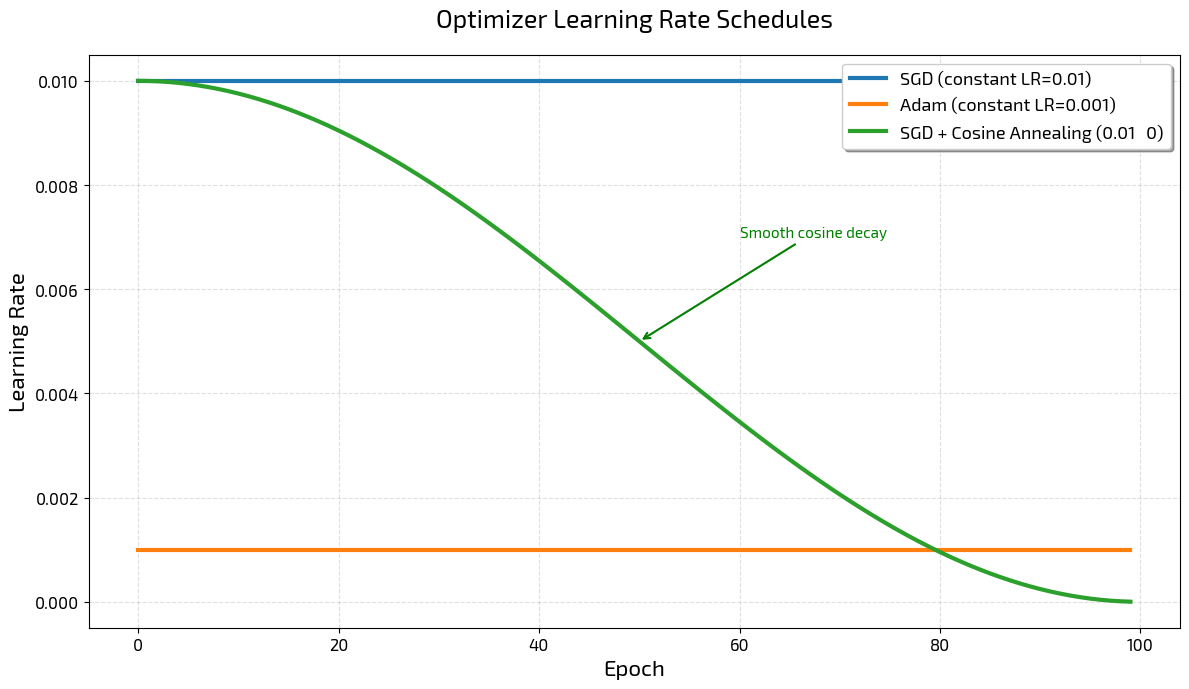


✓ High-resolution figure saved as 'optimizer_comparison_publication.png'


In [10]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Set the font path to your preferred font (e.g., Exo2-Regular.ttf)
font_path = os.path.join( "style", "Exo2-Regular.ttf")
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
    plt.rcParams['font.sans-serif'] = prop.get_name()
    print(f"Using custom font: {prop.get_name()}")
else:
    print("Custom font file not found, using default font.")

# ...existing code...

# Create dummy model
model = torch.nn.Linear(10, 1)

# Setup epochs
epochs = 100

# Create three separate optimizer instances
optimizer_sgd = optim.SGD(model.parameters(), lr=0.01)
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
optimizer_cosine = optim.SGD(model.parameters(), lr=0.01)

# Create scheduler for cosine annealing
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_cosine, T_max=epochs, eta_min=0)

# Track learning rates
lrs_sgd = []
lrs_adam = []
lrs_cosine = []

for epoch in range(epochs):
    # Record learning rates
    lrs_sgd.append(optimizer_sgd.param_groups[0]['lr'])
    lrs_adam.append(optimizer_adam.param_groups[0]['lr'])
    lrs_cosine.append(optimizer_cosine.param_groups[0]['lr'])
    
    # Step the scheduler
    scheduler.step()

# Create enhanced plot
plt.figure(figsize=(12, 7))
plt.plot(range(epochs), lrs_sgd, label='SGD (constant LR=0.01)', 
         linewidth=3, color='#1f77b4', linestyle='-')
plt.plot(range(epochs), lrs_adam, label='Adam (constant LR=0.001)', 
         linewidth=3, color='#ff7f0e', linestyle='-')
plt.plot(range(epochs), lrs_cosine, label='SGD + Cosine Annealing (0.01→0)', 
         linewidth=3, color='#2ca02c', linestyle='-')

plt.xlabel('Epoch', fontsize=16, fontweight='bold')
plt.ylabel('Learning Rate', fontsize=16, fontweight='bold')
plt.title('Optimizer Learning Rate Schedules', fontsize=18, fontweight='bold', pad=20)
plt.legend(fontsize=13, loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
plt.tick_params(axis='both', which='major', labelsize=12)

# Add annotations
plt.annotate('Smooth cosine decay', xy=(50, 0.005), xytext=(60, 0.007),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
            fontsize=11, color='green')

plt.tight_layout()
plt.savefig('optimizer_comparison_publication.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ High-resolution figure saved as 'optimizer_comparison_publication.png'")


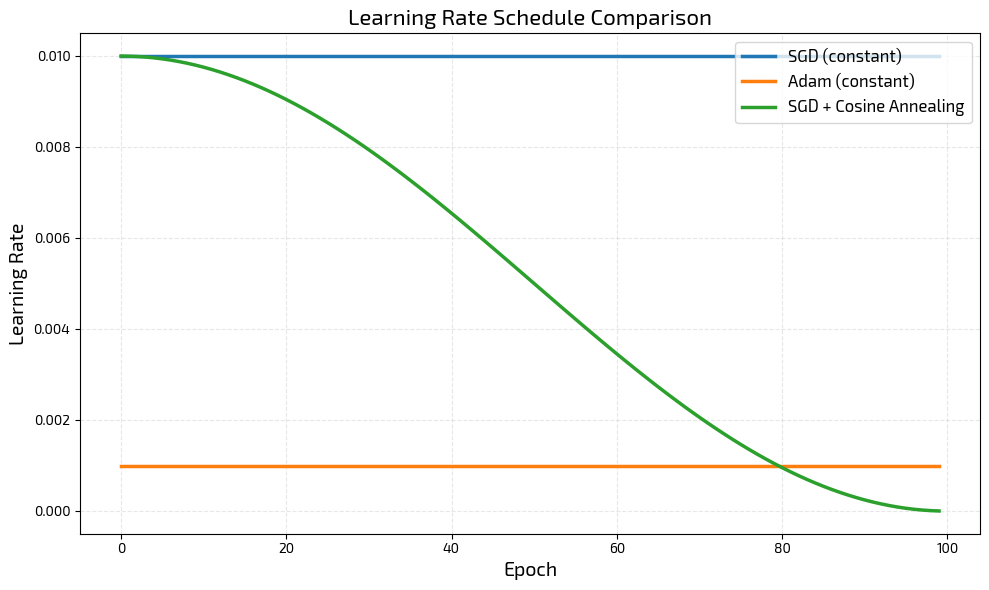

Learning rate ranges:
SGD: 0.0100 (constant)
Adam: 0.0010 (constant)
Cosine: 0.0100 → 0.0000


In [11]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Setup
epochs = 100
lr_sgd = 0.01
lr_adam = 0.001

# Create dummy model (just need parameters for optimizer)
dummy_model = torch.nn.Linear(10, 1)

# Track learning rates
lrs_sgd = []
lrs_adam = []
lrs_cosine = []

# SGD - constant learning rate
for epoch in range(epochs):
    lrs_sgd.append(lr_sgd)

# Adam - constant learning rate
for epoch in range(epochs):
    lrs_adam.append(lr_adam)

# Cosine Annealing - manually compute the schedule
for epoch in range(epochs):
    lr = 0.0 + (lr_sgd - 0.0) * 0.5 * (1 + np.cos(np.pi * epoch / epochs))
    lrs_cosine.append(lr)

# Create publication-quality plot
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), lrs_sgd, label='SGD (constant)', linewidth=2.5, color='#1f77b4')
plt.plot(range(epochs), lrs_adam, label='Adam (constant)', linewidth=2.5, color='#ff7f0e')
plt.plot(range(epochs), lrs_cosine, label='SGD + Cosine Annealing', linewidth=2.5, color='#2ca02c')

plt.xlabel('Epoch', fontsize=14, fontweight='bold')
plt.ylabel('Learning Rate', fontsize=14, fontweight='bold')
plt.title('Learning Rate Schedule Comparison', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Save high-resolution figure for paper
plt.savefig('optimizer_comparison_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

print("Learning rate ranges:")
print(f"SGD: {lr_sgd:.4f} (constant)")
print(f"Adam: {lr_adam:.4f} (constant)")
print(f"Cosine: {max(lrs_cosine):.4f} → {min(lrs_cosine):.4f}")
